# 01 · Exploratory data analysis

FPLense predicts FPL points per player-fixture. Before modelling: how noisy is the target, which
signals carry information, and how hard is the naive baseline to beat?

Data: the DuckDB views from P2 (`v_player_match`, `v_features`) over the Parquet lake, 10 completed
seasons (2016-17 to 2025-26). Rebuild with `python -m fPLense.pipeline --build` if needed.

**Regulars** (used throughout, as in the evaluation) = players whose *lagged* average minutes over
their previous 3 fixtures is at least 45 (`minutes_r3 >= 45`), so the subset is known before the
deadline.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from fPLense import config
from fPLense.db.build import build
from fPLense.models.baselines import rolling_baseline
from fPLense.models.train import add_regular_flag

sns.set_theme(style="whitegrid", context="notebook")
POS_ORDER = ["GK", "DEF", "MID", "FWD"]
con = build(":memory:")
seasons = ", ".join(f"'{s}'" for s in config.SEASONS)
feat = add_regular_flag(con.sql(f"select * from v_features where season in ({seasons})").df())
pm = con.sql(f"select * from v_player_match where season in ({seasons})").df()
print(f"v_features: {len(feat):,} rows, {feat.regular.sum():,} regulars ({feat.regular.mean():.1%})")
print(f"rows with minutes > 0: {(pm.minutes > 0).mean():.1%}")

v_features: 253,578 rows, 82,048 regulars (32.4%)
rows with minutes > 0: 42.9%


## 1. Points distribution by position

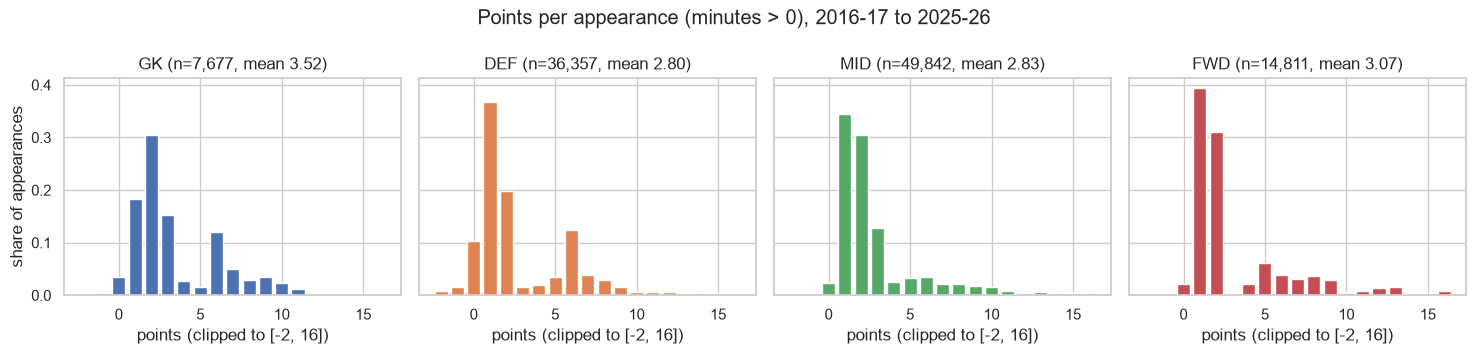

,mean,sd,share <= 2 pts,share >= 10 pts
position,,,,
GK,3.521,2.813,0.527,0.043
DEF,2.804,3.018,0.692,0.031
MID,2.840,2.879,0.676,0.047
FWD,3.081,3.263,0.729,0.052


In [2]:
played = pm[pm.minutes > 0].copy()
played["pts"] = played.total_points.clip(-2, 16)
fig, axes = plt.subplots(1, 4, figsize=(15, 3.6), sharey=True)
for ax, pos in zip(axes, POS_ORDER, strict=True):
    s = played.loc[played.position == pos, "pts"]
    share = s.value_counts(normalize=True).sort_index()
    ax.bar(share.index, share.values, color=sns.color_palette()[POS_ORDER.index(pos)])
    ax.set_title(f"{pos} (n={len(s):,}, mean {s.mean():.2f})")
    ax.set_xlabel("points (clipped to [-2, 16])")
axes[0].set_ylabel("share of appearances")
fig.suptitle("Points per appearance (minutes > 0), 2016-17 to 2025-26")
plt.tight_layout()
plt.show()
summary = played.groupby("position").total_points.agg(["mean", "std", lambda s: (s <= 2).mean(),
                                                         lambda s: (s >= 10).mean()])
summary.columns = ["mean", "sd", "share <= 2 pts", "share >= 10 pts"]
summary.loc[POS_ORDER].round(3)

**Takeaway.** The target is spiky and heavy-tailed: 53–73% of appearances score ≤ 2 points, only 3–5% reach 10+, and the SD (2.8–3.3) is as large as the mean (2.8–3.5). GKs have the highest mean but the thinnest tail; forwards the fattest tail. MAE will sit around 2 points per appearance even for a good model.

## 2. Points vs recent minutes (`minutes_r3`)

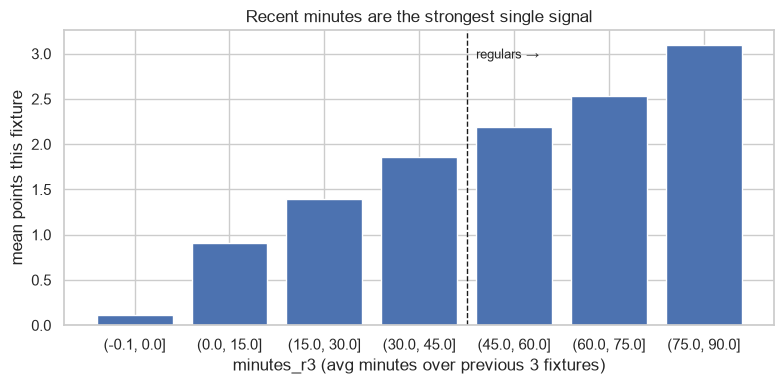

,n,mean_pts,p_plays
min_bin,,,
"(-0.1, 0.0]",114095,0.116,0.057
"(0.0, 15.0]",22134,0.909,0.446
"(15.0, 30.0]",17382,1.392,0.531
"(30.0, 45.0]",11724,1.863,0.660
"(45.0, 60.0]",18384,2.192,0.705
"(60.0, 75.0]",11406,2.536,0.799
"(75.0, 90.0]",51039,3.101,0.877


In [3]:
bins = [-0.1, 0, 15, 30, 45, 60, 75, 90]
feat["min_bin"] = pd.cut(feat.minutes_r3.astype(float), bins)
by_min = feat.groupby("min_bin", observed=True).agg(n=("y", "size"), mean_pts=("y", "mean"),
                                                    p_plays=("y", lambda s: (s != 0).mean()))
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(by_min.index.astype(str), by_min.mean_pts, color="#4c72b0")
ax.set_xlabel("minutes_r3 (avg minutes over previous 3 fixtures)")
ax.set_ylabel("mean points this fixture")
ax.axvline(3.5, color="k", ls="--", lw=1)
ax.text(3.6, by_min.mean_pts.max() * 0.95, "regulars →", fontsize=9)
ax.set_title("Recent minutes are the strongest single signal")
plt.tight_layout()
plt.show()
by_min.round(3)

**Takeaway.** Expected points rise monotonically with recent minutes: 0.12 points for players who didn't play in their last 3 fixtures vs 3.10 for 75–90 minute regulars. Rows with `minutes_r3 = 0` are 45% of the data and almost always score 0, which is why metrics on all rows look flattering and the headline metric uses regulars (`minutes_r3 >= 45`, 32% of rows).

## 3. Autocorrelation of points (lags 1–5), regulars

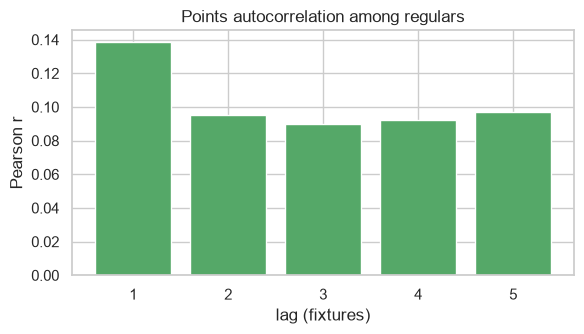

,lag,corr,n
0,1,0.139,77166
1,2,0.095,77166
2,3,0.090,77166
3,4,0.092,74795
4,5,0.097,72400


In [4]:
pmo = pm.sort_values(["season", "element", "gw", "kickoff_time"]).copy()
g = pmo.groupby(["season", "element"]).total_points
regular_now = (
    pmo.groupby(["season", "element"]).minutes.transform(lambda s: s.shift(1).rolling(3).mean())
    >= 45
)
acf = []
for lag in range(1, 6):
    lagged = g.shift(lag)
    m = regular_now & lagged.notna()
    acf.append({"lag": lag, "corr": pmo.total_points[m].corr(lagged[m]), "n": int(m.sum())})
acf = pd.DataFrame(acf)
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(acf.lag, acf["corr"], color="#55a868")
ax.set_xlabel("lag (fixtures)")
ax.set_ylabel("Pearson r")
ax.set_title("Points autocorrelation among regulars")
plt.tight_layout()
plt.show()
acf.round(3)

**Takeaway.** Even among regulars, last fixture's points correlate only r = 0.14 with this fixture's, and lags 2–5 sit around 0.09–0.10. Form is a weak signal: most of a player's score is fixture-level noise, so a 5-game average (B0) is a sensible but beatable baseline. The flat tail beyond lag 1 says longer windows (season average) carry information too.

## 4. Mean points by FDR × home/away (regulars, 2018-19+)

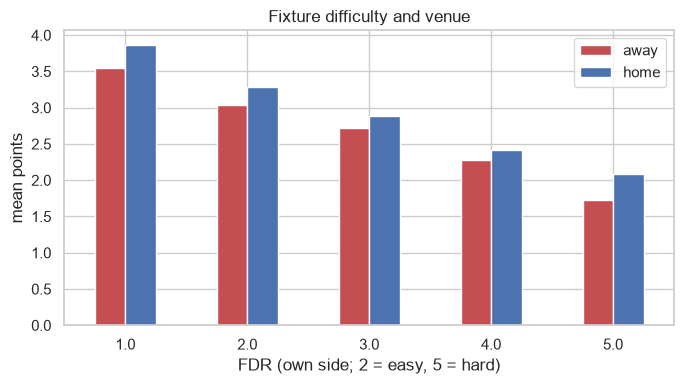

,away,home,n
fdr,,,
1.0,3.547,3.871,1223
2.0,3.043,3.281,24183
3.0,2.722,2.880,21944
4.0,2.282,2.416,14079
5.0,1.720,2.080,4143


In [5]:
r = feat[feat.regular & feat.fdr.notna()]
fdr_tab = r.pivot_table(index="fdr", columns="was_home", values="y", aggfunc="mean")
fdr_tab.columns = ["away", "home"]
fdr_n = r.groupby("fdr").size()
fig, ax = plt.subplots(figsize=(7, 4))
fdr_tab.plot(kind="bar", ax=ax, color=["#c44e52", "#4c72b0"], rot=0)
ax.set_xlabel("FDR (own side; 2 = easy, 5 = hard)")
ax.set_ylabel("mean points")
ax.set_title("Fixture difficulty and venue")
plt.tight_layout()
plt.show()
fdr_tab.assign(n=fdr_n).round(3)

**Takeaway.** FDR has a clear, monotone effect: regulars average 3.04 (away) / 3.28 (home) at FDR 2 against 1.72 / 2.08 at FDR 5, and home adds 0.13–0.36 points at every difficulty. Fixture context is worth including, though FDR is coarse (5 levels, set pre-season), which is what the odds features refine.

## 5. Recent xGI (`xgi_r5`) vs next-fixture points (regulars, 2022-23+)

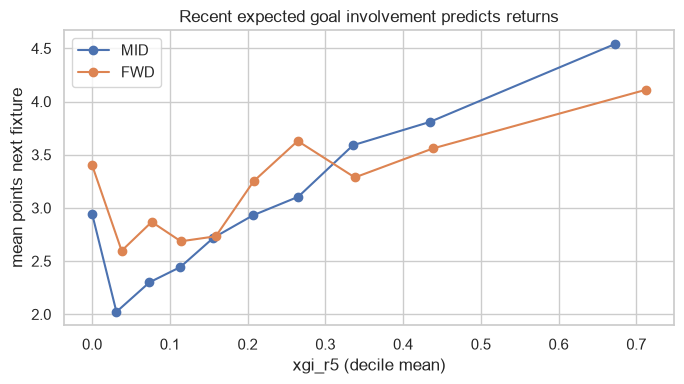

Spearman(xgi_r5, y): 0.165 | Spearman(goals_r5 + assists_r5, y): 0.188


In [6]:
x = feat[feat.regular & feat.xgi_r5.notna() & feat.position.isin(["MID", "FWD"])].copy()
x["xgi_bin"] = pd.qcut(x.xgi_r5, 10, duplicates="drop")
xb = x.groupby(["xgi_bin", "position"], observed=True).agg(xgi=("xgi_r5", "mean"), pts=("y", "mean"))
xb = xb.reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
for pos in ["MID", "FWD"]:
    d = xb[xb.position == pos]
    ax.plot(d.xgi, d.pts, marker="o", label=pos)
ax.set_xlabel("xgi_r5 (decile mean)")
ax.set_ylabel("mean points next fixture")
ax.set_title("Recent expected goal involvement predicts returns")
ax.legend()
plt.tight_layout()
plt.show()
print("Spearman(xgi_r5, y):", round(x[["xgi_r5", "y"]].corr("spearman").iloc[0, 1], 3),
      "| Spearman(goals_r5 + assists_r5, y):",
      round(pd.concat([x.goals_r5 + x.assists_r5, x.y], axis=1).corr("spearman").iloc[0, 1], 3))

**Takeaway.** For MID/FWD regulars, points climb steadily with recent xGI, steeper for forwards. The rank correlation is modest (Spearman 0.17) and actual goals + assists over 5 games is about as informative (0.19), so xG adds information alongside, not instead of, raw returns. xG exists only from 2022-23; LightGBM sees NaN before then.

## 6. MAE of the naive baseline (B0) across gameweeks, regulars

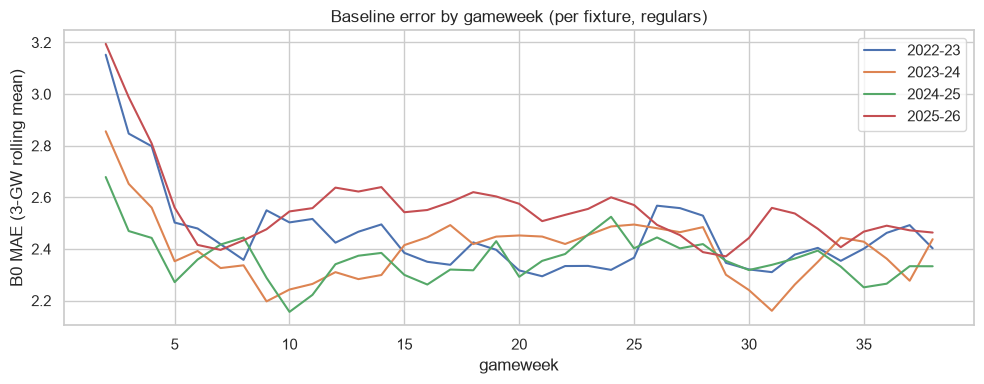

B0 MAE, regulars: GW2-4 2.677 | GW5+ 2.399


season,2016-17,2017-18,2018-19,2019-20,2020-21,2021-22,2022-23,2023-24,2024-25,2025-26
B0 MAE (regulars),2.446,2.385,2.417,2.386,2.429,2.436,2.431,2.394,2.356,2.537


In [7]:
feat["b0"] = rolling_baseline(feat)
feat["abs_err"] = (feat.y - feat.b0).abs()
mae_gw = feat[feat.regular].groupby(["season", "gw"]).abs_err.mean().reset_index()
fig, ax = plt.subplots(figsize=(10, 4))
for season in ["2022-23", "2023-24", "2024-25", "2025-26"]:
    d = mae_gw[mae_gw.season == season]
    ax.plot(d.gw, d.abs_err.rolling(3, min_periods=1).mean(), label=season)
ax.set_xlabel("gameweek")
ax.set_ylabel("B0 MAE (3-GW rolling mean)")
ax.set_title("Baseline error by gameweek (per fixture, regulars)")
ax.legend()
plt.tight_layout()
plt.show()
season_mae = feat[feat.regular].groupby("season").abs_err.mean()
print("B0 MAE, regulars: GW2-4", round(feat[feat.regular & (feat.gw < 5)].abs_err.mean(), 3),
      "| GW5+", round(feat[feat.regular & (feat.gw >= 5)].abs_err.mean(), 3))
season_mae.round(3).to_frame("B0 MAE (regulars)").T

**Takeaway.** B0's per-fixture MAE on regulars is stable across seasons (2.36–2.54); 2025-26, the evaluation season, is the hardest of the ten (2.54). Error is highest in the first gameweeks (GW2–4 mean 2.68 vs 2.40 from GW5), when the 5-game window is short. That's why the walk-forward evaluation starts at GW5.

## 7. DEFCON hit rates by position, 2025-26

From 2025-26, defenders score +2 for 10+ CBIT and midfielders/forwards +2 for 12+ CBIRT.
`defensive_contribution` is the counted total; the threshold depends on position.

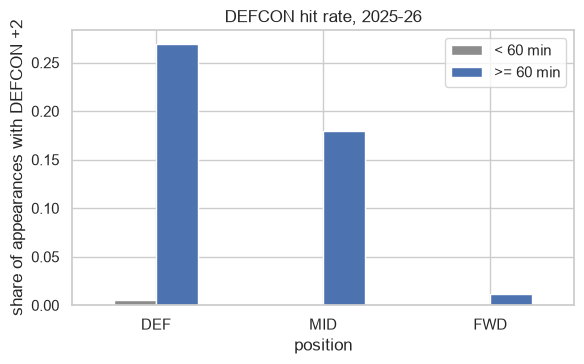

,< 60 min,>= 60 min
position,,
DEF,0.005,0.270
MID,0.001,0.179
FWD,0.000,0.012


In [8]:
d = pm[(pm.season == "2025-26") & (pm.minutes > 0) & (pm.position != "GK")].copy()
d["threshold"] = np.where(d.position == "DEF", 10, 12)
d["hit"] = d.defensive_contribution >= d.threshold
d["mins60"] = d.minutes >= 60
dc = d.groupby(["position", "mins60"]).hit.mean().unstack()
dc.columns = ["< 60 min", ">= 60 min"]
dc = dc.loc[["DEF", "MID", "FWD"]]
fig, ax = plt.subplots(figsize=(6, 3.8))
dc.plot(kind="bar", ax=ax, rot=0, color=["#8c8c8c", "#4c72b0"])
ax.set_ylabel("share of appearances with DEFCON +2")
ax.set_title("DEFCON hit rate, 2025-26")
plt.tight_layout()
plt.show()
dc.round(3)

**Takeaway.** DEFCON is mostly a defender bonus: 27% of 60+ minute DEF appearances earned +2 in 2025-26, vs 18% for MIDs and 1% for FWDs, and it almost never happens in sub-60-minute cameos. It's one season of data, so `defcon_r5` is NaN for the other nine and the model can only learn from 2025-26 rows.

## 8. Bookmaker-implied team goals vs player points (regulars)

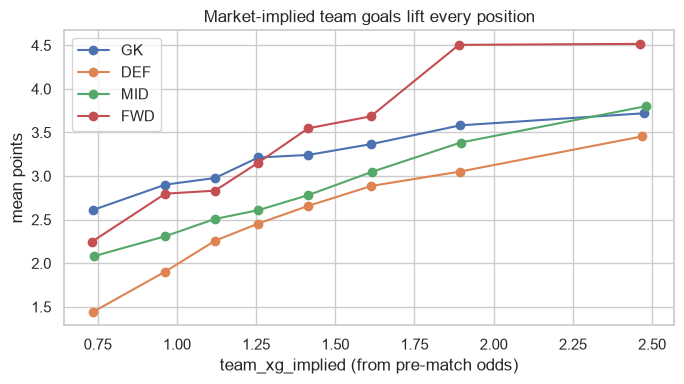

xg_bin,"(0.242, 0.869]","(2.091, 3.557]"
position,,
GK,2.61,3.72
DEF,1.44,3.46
MID,2.08,3.80
FWD,2.25,4.52


In [9]:
o = feat[feat.regular].copy()
o["xg_bin"] = pd.qcut(o.team_xg_implied, 8)
ob = o.groupby(["xg_bin", "position"], observed=True).agg(lam=("team_xg_implied", "mean"),
                                                          pts=("y", "mean")).reset_index()
fig, ax = plt.subplots(figsize=(7, 4))
for pos in POS_ORDER:
    s = ob[ob.position == pos]
    ax.plot(s.lam, s.pts, marker="o", label=pos)
ax.set_xlabel("team_xg_implied (from pre-match odds)")
ax.set_ylabel("mean points")
ax.set_title("Market-implied team goals lift every position")
ax.legend()
plt.tight_layout()
plt.show()
ob.pivot(index="position", columns="xg_bin", values="pts").loc[POS_ORDER].iloc[:, [0, -1]].round(2)

**Takeaway.** Bookmaker-implied team goals are a strong, forward-looking signal for every position: moving from the lowest to the highest implied-goals octile roughly doubles mean points for FWD (2.25 → 4.52) and more than doubles them for DEF (1.44 → 3.46, via clean sheets). Unlike FDR it varies continuously by fixture and is priced before the deadline.

## Summary

1. Minutes/role dominate: who plays matters more than how well they've played.
2. Form is weak (lag-1 r = 0.14), so the ceiling on accuracy is low; judge models on regulars and against B0.
3. Fixture context (FDR, home, and especially odds-implied goals) shifts expected points by 1–2 points per fixture.
4. xG and DEFCON are partial-history features (2022-23+, 2025-26): kept as NaN elsewhere, never 0.
5. Evaluate from GW5, where the rolling windows are populated.